# Projet Régression Logistique

Ce projet a pour objectif d'implémenter entièrement une régression logistique en Python sans utiliser de bibliothèque de machine learning. L'objectif est de construire un modèle capable de prédire la présence ou l'absence de pluie à partir de différentes variables météorologiques.

Pour cela, nous avons :
- codé une régression logistique à partir de zéro ;
- implémenté une descente de gradient pour l'apprentissage des paramètres ;
- évalué les performances du modèle sur des données de test ;
- interprété les coefficients obtenus afin d'identifier les variables les plus influentes dans la prédiction.

In [1]:
#Importation des librairies autorisées
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## 1. Chargement des données
Nous importons le dataset contenant les variables météorologiques.

In [13]:
#Importation du data set
data= pd.read_csv("weather_forecast_data.csv")

#Les cinq premiere lignes du dataset
data.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


## Vérification des données
- valeurs manquantes
- doublons
- valeurs aberrantes

In [15]:
#Valeurs manquantes
print(data.isnull().sum())

#Doublons
print(data.duplicated().sum())

#On cherche les valeurs aberrantes avec le z-score
#from scipy import stats

#Interprétation de la valeurs abberrante
#z = stats.zscore(data["Temperature"])
#outliers = data[(z > 3) | (z < -3)]
#print(outliers)

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64
0


### Sélection des variables explicatives

L'analyse des corrélations montre que **Humidity**, **Cloud_Cover** et **Temperature** sont les variables les plus liées à la variable cible **Rain**. Ces trois variables ont donc été retenues pour l'entraînement de la régression logistique.

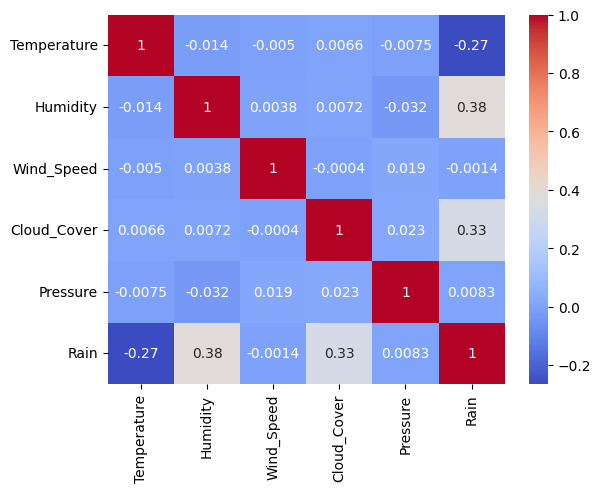

In [ ]:
#Encodage de la cible "Rain" : on encode la variable en nombres
data["Rain"]= data["Rain"].map({"no rain": 0, "rain": 1})

#Correlation
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
#data est bien un DataFrame panda
#type(data)

pandas.core.frame.DataFrame

## Séparation des variables

### 1. Définition des variables

- **X** : ensemble des variables explicatives utilisées pour prédire la pluie.
- **Y** : variable cible (*Rain*), représentant la présence ou l'absence de pluie.

In [ ]:
#Séparation des variables

#variable explicative
X = data[["Temperature","Humidity","Cloud_Cover"]]

#variable cible 
Y = data["Rain"]

### 2. Découpage du jeu de données

Le jeu de données est ensuite divisé en trois sous-ensembles :

- **Ensemble d'entraînement (Train)** : utilisé pour apprendre les paramètres du modèle.
- **Ensemble de validation (Validation)** : utilisé pour suivre les performances du modèle pendant l'entraînement et détecter un éventuel sur-apprentissage.
- **Ensemble de test (Test)** : utilisé uniquement à la fin pour évaluer les performances du modèle sur des données jamais vues.

In [ ]:

m = len(X)
indices = np.random.permutation(m)
train_size = int(0.75* m)     # 75% pour l'entraînement
val_size = int(0.05 * m)      # 5% pour la validation
# Le reste (environ 20%) ira au test


train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

X_train = X.iloc[train_idx].reset_index(drop=True)
Y_train = Y.iloc[train_idx].reset_index(drop=True)

# Ensemble de Validation
X_val = X.iloc[val_idx].reset_index(drop=True)
Y_val = Y.iloc[val_idx].reset_index(drop=True)

# Ensemble de Test
X_test = X.iloc[test_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)



In [ ]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1875, 3)
(125, 3)
(500, 3)


In [ ]:
trainset_size  = len(X_train)
valset_size = len(X_val)

In [ ]:
print(X_train.values.shape)

(1875, 3)


## Standardisation des variables

Les variables sont centrées et réduites afin d’avoir une moyenne nulle et un écart-type égal à 1.

Cela permet d’améliorer la convergence de la descente de gradient.

In [ ]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

## Régression logistique

In [ ]:
#Implémentation de la fonction sigmoïde 
def sigmoid(z) : 
    return 1/(1+np.exp(-z))

In [ ]:
#print(X_train)
#print(Y_train.values.reshape(-1,1).shape)
#print(a)

In [ ]:
y = Y_train.values.reshape(-1,1)

In [ ]:
#Fonction coût (log-loss)
def J(a,y) :
    epsilon = 1e-15
    a = np.clip(a, epsilon, 1-epsilon)
    m = len(y) 
    return -1/m * np.sum(y*np.log(a) + (1-y)*np.log(1-a))

In [ ]:
#def J(a,Y_train) :
    #return -(1/m)*(Y_train.values.reshape(-1,1) @ np.log(a) + (1-Y_train.values.reshape(-1,1)) @ np.log(1-a))

In [ ]:
#pas d'apprentissage
learning_rate=0.01

In [ ]:
print(X_train.values.reshape(-1,1))

[[ 1.27637036]
 [-1.30112283]
 [ 0.06378381]
 ...
 [ 1.10838043]
 [ 0.04939297]
 [ 0.23953375]]


In [ ]:
print(y.shape)
n = X_train.shape[1]
train_costs = []
val_costs = []
w = np.zeros((n,1))
b = 0
print(w)

(1875, 1)
[[0.]
 [0.]
 [0.]]


In [ ]:
"""
Cette fonction calcul les gradients dw  et db.

Elle prend en entrée : 
    X : La matrice des variables explicatives (m,n)
    y : vecteur des vraies classes de taille (m,1)
    a : vecteur des probabilités prédites par le modèle de taille (m,1)

"""

# Fonction de calcul des gradients 
def compute_gradients(X, y, a):
    
    #nombre d'observations
    m = len(y)
    
    #Calcul des gradients
    #dw est la moyenne des contributions de chaque variable à
    #l'erreur du modèle
    dw = (1/m) * X.T @ (a-y)
    #db est l'erreur moyenne globale du modèle et indique comment
    #corriger le biais
    db = (1/m)* np.sum(a-y)
    
    return dw, db

## Entraînement de notre modèle 

In [ ]:
"""
Cette fonction entraîne un modèle de régression logistique avec une descente de gradient.

    Entrées :
     X_train : variables explicatives de l'ensemble d'entraînement
     Y_train : vraies classes de l'ensemble d'entraînement
     X_val : variables explicatives de l'ensemble de validation
     Y_val : vraies classes de l'ensemble de validation
     learning_rate : pas d'apprentissage, c'est-à-dire la taille des corrections appliquées à w et b
     n_iterations : nombre de fois où l'on répète la descente de gradient

    Sorties :
     w : poids appris par le modèle
     b : biais appris par le modèle
     train_costs : valeurs de la fonction coût sur l'ensemble d'entraînement
     val_costs : valeurs de la fonction coût sur l'ensemble de validation
"""


def train_logistic_regression(
        X_train,
        Y_train,
        X_val,
        Y_val,
        learning_rate,
        n_iterations=10000):

    m = len(X_train)
    n = X_train.shape[1]

    w = np.zeros((n,1))
    b = 0

    train_costs = []
    val_costs = []

    y_train = Y_train.values.reshape(-1,1)
    y_val = Y_val.values.reshape(-1,1)

    for i in range(n_iterations):

        # train
        z_train = X_train.values @ w + b
        a_train = sigmoid(z_train)

        train_cost = J(a_train,y_train)
        train_costs.append(train_cost)

        # validation
        z_val = X_val.values @ w + b
        a_val = sigmoid(z_val)

        val_cost = J(a_val,y_val)
        val_costs.append(val_cost)

        # gradients
        dw = (1/m) * X_train.values.T @ (a_train-y_train)
        db = (1/m) * np.sum(a_train-y_train)

        # mise à jour
        w -= learning_rate * dw
        b -= learning_rate * db

    return w,b,train_costs,val_costs

In [ ]:
# Entraînement du modèle de régression logistique à l'aide de la descente de gradient.
# La fonction retourne les paramètres optimisés (w et b) ainsi que l'évolution
# de la fonction coût sur les ensembles d'entraînement et de validation.

# w : poids finaux appris pour chaque variable.
# b : biais final appris par le modèle.
# train_costs : historique du coût sur l'ensemble d'entraînement.
# val_costs : historique du coût sur l'ensemble de validation.

w,b,train_costs,val_costs = train_logistic_regression(
    X_train,
    Y_train,
    X_val,
    Y_val,
    learning_rate=0.01,
    n_iterations=10000
)

In [ ]:
print(w)
print(b)

[[-1.29800239]
 [ 1.81558405]
 [ 1.52762113]]
-3.6211341375087867


## Visulisation de l'apprentissage du modèle 
### Graphique des coûts 

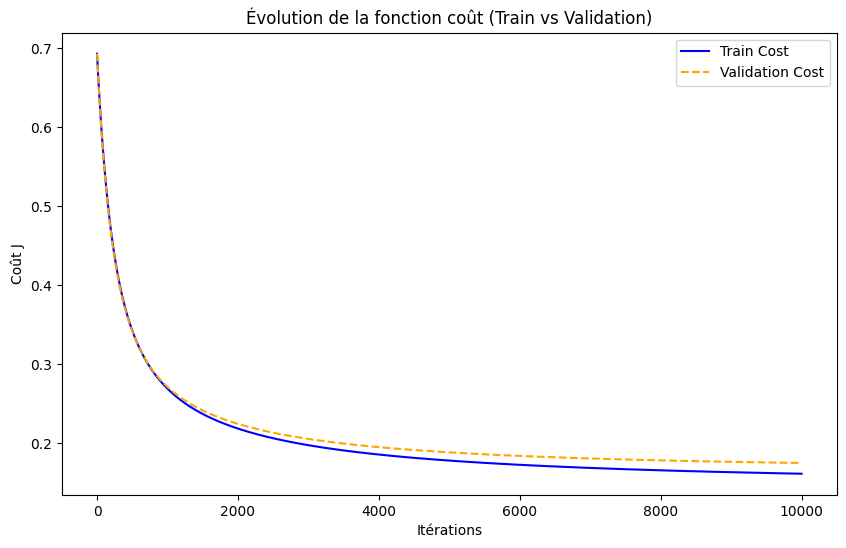

In [ ]:
# Affichage du graphique comparatif (Source [5, 6])
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train Cost", color='blue')
plt.plot(val_costs, label="Validation Cost", color='orange', linestyle='--')
plt.title("Évolution de la fonction coût (Train vs Validation)")
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.legend()
plt.show()

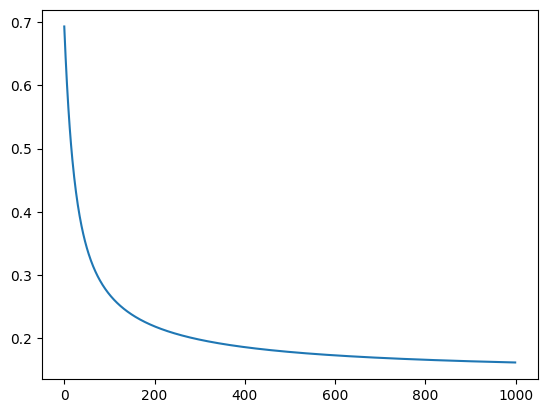

In [ ]:
plt.plot(train_costs[::10])

## Prédictions sur l'ensemble du test

In [ ]:
z_test = X_test.values @ w + b
a_test = sigmoid(z_test)
TN = FP = FN = TP = 0

In [ ]:
y_true = Y_test.values.reshape(-1,1)

#On transforme la probabilité a_test en classe
y_pred = (a_test >= 0.5).astype(int)

for i in range(len(y_true)):
    if y_true[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y_true[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y_true[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y_true[i] == 1 and y_pred[i] == 0:
        FN += 1

In [ ]:
#Matrice de confusion
cm = np.array([[TN, FP],
               [FN, TP]])

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[423  10]
 [ 28  39]]


## Évaluation des performances

In [ ]:
#on évalue les performances

#mesure le total du nombre de pourcentage correct
accuracy=((TP+TN)/(TP+TN+FP+FN))*100

#mesure combien des cas predits, sont vraiment des cas pluies
precision= (TP/(TP+FP))*100

#dectection de nombre de vrais de pluie
recall=(TP/(TP+FN))*100

#Le F1-score est la moyenne harmonique entre précision et rappel
f1 = (2 * ((precision * recall) / (precision + recall)))

print(f"Accuracy  : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 92.4000
Précision : 79.5918
Rappel    : 58.2090
F1-score  : 67.2414


## Interprétation des résultats et analyse des coefficients
On interpréste les coefficients du modèle pour identifier les variables les plus influentes. 

In [ ]:
#On affiche les coefficients que l'on va interpréter

for nom, poids in zip(X_train.columns, w.flatten()): 
    print(f"{nom} : {poids:.4f}")

Temperature : -1.2980
Humidity : 1.8156
Cloud_Cover : 1.5276


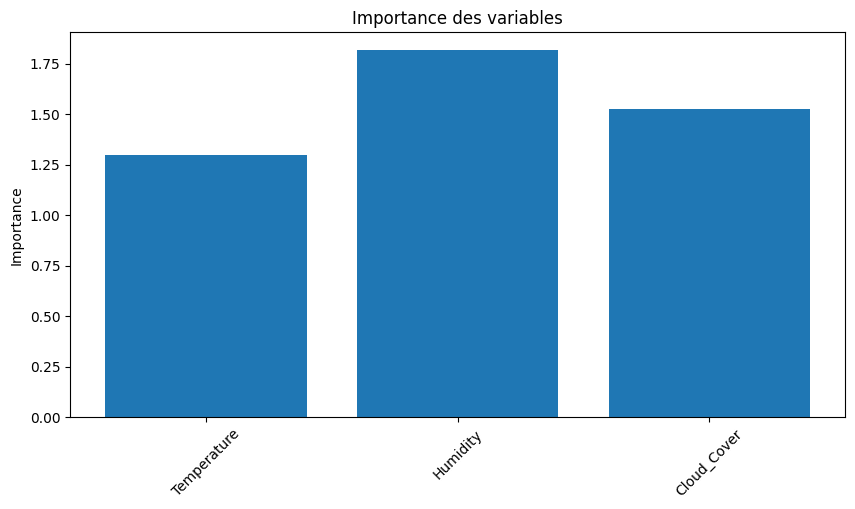

In [ ]:
#Affichage du graphique de l'importance des variables
plt.figure(figsize=(10,5))
plt.bar(X_train.columns, np.abs(w.flatten()))
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.title("Importance des variables")
plt.show()

On remarque que l'humidité est de 1.8156 tandis que la couverture nuageuse est à 1.5276 et la température à -1.2980. L'humidité semble être le coefficient qui prédis le mieux la pluie. Une augmentation de l'humidité accroît la probabilité de pluie. À l'inverse, l'ensoileillement possède un coefficient négatif important, ce qui signifie qu'une forte durée d'ensoleillement réduit la probabilité qu'il pleuve.

# Limites du modèle

# Conclusion